## About Dataset
📘 About This Dataset
This dataset contains student performance records, capturing key academic and personal factors that influence exam outcomes 🎓. It helps data enthusiasts, researchers, and ML practitioners explore how attributes such as study hours, parental education, extracurricular activities, and socio-economic conditions shape student scores 📊✨.

With this dataset, you can perform:

📈 Predictive modeling (exam score prediction, risk analysis)
🧠 Educational insights (finding patterns affecting students’ success)
🔍 Exploratory data analysis (correlations, trends, behavior insights)
🤖 Machine learning projects (classification, regression, feature engineering)
Its clean structure and real-world relevance make it ideal for beginners, ML learners, and education researchers looking to build impactful analyses or end-to-end ML projects 🚀.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("StudentPerformance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


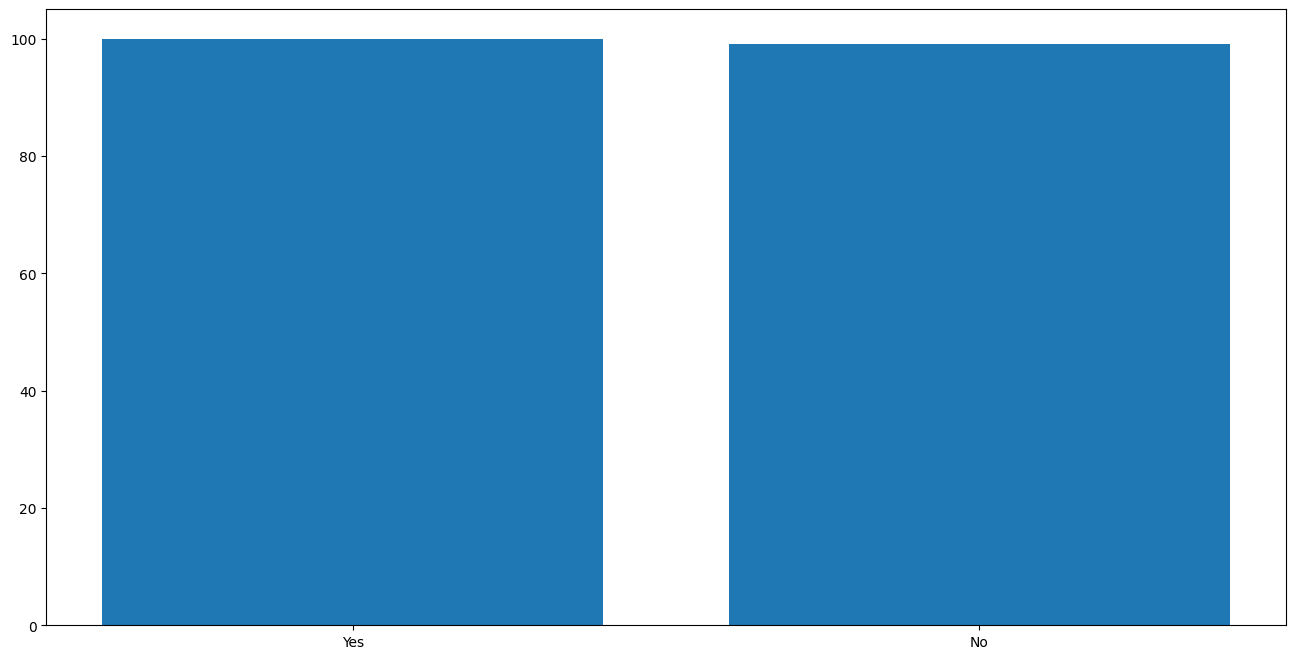

In [5]:
plt.figure(figsize=(16,8))
plt.bar(df["Extracurricular Activities"],df["Performance Index"])
plt.show()

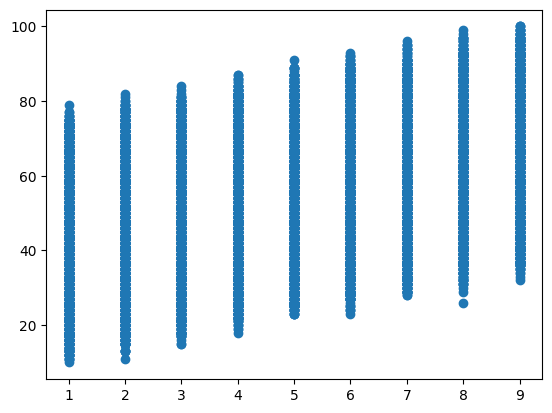

In [6]:
plt.scatter(df["Hours Studied"],df["Performance Index"])
plt.show()

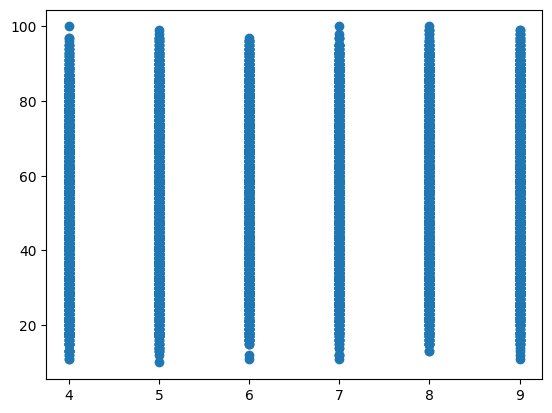

In [7]:
plt.scatter(df["Sleep Hours"],df["Performance Index"])

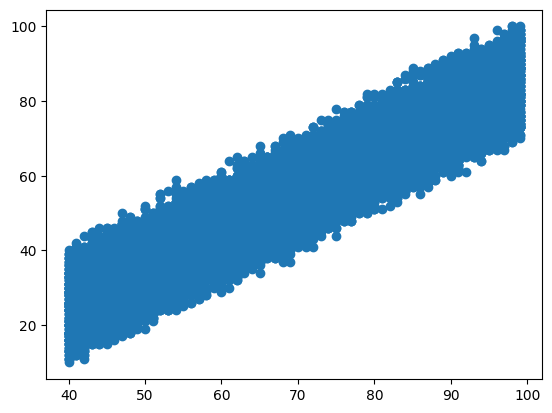

In [8]:
plt.scatter(df["Previous Scores"],df["Performance Index"])
plt.show()

In [9]:
fig = px.scatter(df,x=df["Previous Scores"],y=df["Performance Index"],color=df["Extracurricular Activities"])
fig.show()

In [10]:
fig = px.bar(df,x=df["Sample Question Papers Practiced"],y=df["Performance Index"],color=df["Extracurricular Activities"]
             )

fig.show()

In [11]:
fig = px.scatter(df,x=df["Sample Question Papers Practiced"],y=df["Performance Index"],)
fig.show()

In [12]:
fig = px.pie(df,names=df["Hours Studied"],title="Hours Studied")
fig.show()

In [13]:
fig = px.pie(df,names=df["Extracurricular Activities"],title="Extracurricular Activities")
fig.show()

In [14]:
fig = px.pie(df,names=df["Sample Question Papers Practiced"],title="Sample Question Papers Practiced")
fig.show()

In [15]:
fig = px.pie(df,names=df["Sleep Hours"],title="Sleep Hours")
fig.show()

In [16]:
fig = px.funnel(df,x=df["Hours Studied"],y=df["Performance Index"])
fig.show()

In [17]:
fig = px.funnel(df,x=df["Sleep Hours"],y=df["Performance Index"])
fig.show()

In [18]:
fig = px.histogram(df,x=df["Hours Studied"],y=df["Performance Index"])
fig.show()

In [19]:
fig = px.histogram(df,x=df["Hours Studied"],y=df["Performance Index"])
fig.show()

In [20]:
inputs = df.drop("Performance Index",axis=1)
target = df["Performance Index"]
inputs

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2
3,5,52,Yes,5,2
4,7,75,No,8,5
...,...,...,...,...,...
9995,1,49,Yes,4,2
9996,7,64,Yes,8,5
9997,6,83,Yes,8,5
9998,9,97,Yes,7,0


In [25]:
inputs["Extracurricular Activities"] = inputs["Extracurricular Activities"].map({"Yes":1,"No":0})
inputs

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [26]:
from sklearn.model_selection import train_test_split

train_inputs,test_inputs,train_target,test_target = train_test_split(inputs,target,test_size=0.3,random_state=42)
print(train_inputs.shape)
print(train_target.shape)
print(test_inputs.shape)
print(test_target.shape)

(7000, 5)
(7000,)
(3000, 5)
(3000,)


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_inputs,train_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
model.coef_

array([2.85895223, 1.01551979, 0.58171285, 0.47967676, 0.19039416])

In [30]:
pred = model.predict(test_inputs)
pred

array([54.74728554, 22.61884434, 47.93665124, ..., 33.42451751,
       67.92578967, 31.20587077], shape=(3000,))

In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(test_target, pred))
rmse = np.sqrt(mean_squared_error(test_target, pred))
print("RMSE:", rmse)
print("R²:", r2_score(test_target, pred))


MAE: 1.6090437564045248
RMSE: 2.016572295776349
R²: 0.9890110607021136
